# TNBC Regulatory Pipeline Appyter
**ChEA3 → KEA3 → Perturb-Seqr**

This appyter takes a gene set — for example, genes up-regulated in triple-negative breast cancer (TNBC) — and chains together three tools to build a regulatory hypothesis:

1. **ChEA3** infers which transcription factors are most likely driving the gene set.
2. **KEA3** takes those transcription factors and infers the upstream kinases regulating them.
3. **Perturb-Seqr** searches a large connectivity-mapping database of small-molecule and gene perturbation signatures to propose drugs predicted to reverse (or mimic) the original gene signature.

For simplicity, the primary inputs are a gene list and a handful of parameters controlling how many top hits flow through each step. Other parameters are set to reasonable defaults in the cells below — you can download the notebook, change them, and rerun it if you wish.

Each step includes both a results table and a chart summarizing the enrichment/perturbation results. Links to the full, interactive results on the ChEA3, KEA3, and Perturb-Seqr websites are provided at the bottom of each section.

In [1]:
#%%appyter init
from appyter import magic
magic.init(lambda _=globals: _())

In [2]:
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML, Markdown

from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
output_notebook()

Loading BokehJS ...

In [3]:
%%appyter hide_code

{% do SectionField(
    name='section1',
    title='1. Submit Your Gene List',
    subtitle='Upload a text file containing your gene list or copy and paste your gene list into the text box below (one gene per row). You can also try the default TNBC gene set provided.',
) %}
{% do SectionField(
    name='section2',
    title='2. Pipeline Parameters',
    subtitle='Set a query name and choose how many top hits to carry forward at each step of the pipeline.',
) %}

In [4]:
%%appyter hide_code

{% set gene_list_kind = TabField(
    name='gene_list_kind',
    label='Gene List',
    default='Paste',
    description='Paste or upload your gene list',
    required=True,
    choices={
        'Paste': [
            TextListField(
                name='gene_list_input',
                label='Gene List',
                description='Paste your gene list (one gene per row).',
                default=[
                    'MKI67', 'TOP2A', 'MELK', 'FOXM1', 'CCNB1', 'CDK1', 'BIRC5', 'PLK1',
                    'AURKB', 'BUB1', 'CCNA2', 'CDC20', 'CENPF', 'KIF2C', 'NDC80', 'RRM2',
                    'TYMS', 'PTTG1', 'KIF20A', 'ASPM', 'TPX2', 'PRC1', 'NUSAP1', 'KIF11',
                    'DLGAP5', 'HJURP', 'CDCA8', 'TTK', 'HMMR', 'EXO1', 'RAD51', 'BRCA1',
                    'EZH2', 'MYC', 'E2F1', 'E2F2', 'STAT3', 'EGFR', 'VIM', 'FN1',
                    'SNAI1', 'TWIST1', 'ZEB1', 'CDH2', 'MMP9', 'MMP2', 'VEGFA'
                ],
                section='section1'
            ),
        ],
        'Upload': [
            FileField(
                name='gene_list_filename',
                label='Gene List File',
                default='',
                description='Upload your gene list as a text file (one gene per row).',
                section='section1'
            ),
        ],
    },
    section='section1',
) %}

{% set query_name = StringField(
    name='query_name',
    label='Query Name',
    description='A label for this analysis, sent to each API and used in output titles.',
    default='TNBC_up',
    section='section2'
) %}

{% set top_n_tfs = IntField(
    name='top_n_tfs',
    label='Top Transcription Factors (ChEA3 \u2192 KEA3)',
    description='Number of top-ranked ChEA3 transcription factors to carry forward into the KEA3 kinase analysis.',
    default=10,
    min=1,
    max=25,
    section='section2'
) %}

{% set top_n_kinases = IntField(
    name='top_n_kinases',
    label='Top Kinases to Display',
    default=10,
    min=1,
    max=25,
    section='section2'
) %}

{% set top_n_drugs = IntField(
    name='top_n_drugs',
    label='Top Drugs to Display (per direction)',
    description='Number of top drug perturbations to show in each of the Up Drugs and Down Drugs tables/charts.',
    default=12,
    min=1,
    max=50,
    section='section2'
) %}

{% set top_n_genes = IntField(
    name='top_n_genes',
    label='Top Gene Perturbations to Display (per direction)',
    description='Number of top gene (knockout/knockdown) perturbations to show in each of the Up Genes and Down Genes tables/charts.',
    default=12,
    min=1,
    max=50,
    section='section2'
) %}

In [5]:
%%appyter code_exec

{%- if gene_list_kind.raw_value == 'Paste' %}
gene_list_input = {{ gene_list_kind.value[0] }}
{%- else %}
gene_list_filename = {{ gene_list_kind.value[0] }}
{%- endif %}
query_name = {{ query_name }}
top_n_tfs = {{ top_n_tfs }}
top_n_kinases = {{ top_n_kinases }}
top_n_drugs = {{ top_n_drugs }}
top_n_genes = {{ top_n_genes }}

```python
gene_list_input = ['MKI67', 'TOP2A', 'MELK', 'FOXM1', 'CCNB1', 'CDK1', 'BIRC5', 'PLK1', 'AURKB', 'BUB1', 'CCNA2', 'CDC20', 'CENPF', 'KIF2C', 'NDC80', 'RRM2', 'TYMS', 'PTTG1', 'KIF20A', 'ASPM', 'TPX2', 'PRC1', 'NUSAP1', 'KIF11', 'DLGAP5', 'HJURP', 'CDCA8', 'TTK', 'HMMR', 'EXO1', 'RAD51', 'BRCA1', 'EZH2', 'MYC', 'E2F1', 'E2F2', 'STAT3', 'EGFR', 'VIM', 'FN1', 'SNAI1', 'TWIST1', 'ZEB1', 'CDH2', 'MMP9', 'MMP2', 'VEGFA']
query_name = 'TNBC_up'
top_n_tfs = 10
top_n_kinases = 10
top_n_drugs = 12
top_n_genes = 12
```

In [6]:
%%appyter code_exec

{%- if gene_list_kind.raw_value == 'Paste' %}
genes = [x.strip() for x in gene_list_input]
{%- else %}
open_gene_list_file = open(gene_list_filename, 'r')
lines = open_gene_list_file.readlines()
genes = [x.strip() for x in lines]
open_gene_list_file.close()
{%- endif %}
genes = [g for g in genes if g]

# Error handling
class NoResults(Exception):
    pass

class APIFailure(Exception):
    pass

print(f'Gene set loaded: {len(genes)} genes')

```python
genes = [x.strip() for x in gene_list_input]
genes = [g for g in genes if g]
# Error handling
class NoResults(Exception):
    pass
class APIFailure(Exception):
    pass
print(f'Gene set loaded: {len(genes)} genes')
```

Gene set loaded: 47 genes


In [7]:
# Shared helper: horizontal bar chart used to visualize each step's top results
def make_bar_chart(labels, scores, title, xlabel, colors='lightskyblue', legend_handles=None, figsize=None):
    labels = list(labels)
    scores = list(scores)
    if figsize is None:
        figsize = (9, max(3, 0.4 * len(labels)))
    order = np.argsort(scores)  # ascending so the highest score plots at the top
    labels_sorted = [labels[i] for i in order]
    scores_sorted = [scores[i] for i in order]
    if isinstance(colors, (list, tuple, np.ndarray)):
        colors_sorted = [colors[i] for i in order]
    else:
        colors_sorted = colors

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.barh(labels_sorted, scores_sorted, color=colors_sorted, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if legend_handles:
        ax.legend(handles=legend_handles, loc='lower right', frameon=False)
    plt.tight_layout()
    return ax

## Step 1: ChEA3 — Transcription Factor Enrichment
ChEA3 ranks transcription factors by integrating six reference libraries (ChIP-seq, co-expression, and co-occurrence data) and combining them with a mean-rank method. The table below shows the top-ranked transcription factors most likely responsible for regulating the input gene set, along with the genes from your list that overlap each transcription factor's known targets.

Rank,Transcription Factor,Score,Overlapping Genes
1,CENPA,2.00,"T, O, P, 2, A, ,"
2,FOXM1,4.50,"T, O, P, 2, A, ,"
3,DNMT1,8.50,"T, O, P, 2, A, ,"
4,ZNF367,9.67,"T, O, P, 2, A, ,"
5,MYBL2,10.17,"T, O, P, 2, A, ,"
6,TFDP1,13.75,"T, O, P, 2, A, ,"
7,PA2G4,15.50,"H, J, U, R, P, ,"
8,E2F1,17.00,"T, O, P, 2, A, ,"
9,HMGA2,20.67,"T, O, P, 2, A, ,"
10,E2F7,24.80,"T, O, P, 2, A, ,"


**Table 1. Top 10 transcription factors inferred by ChEA3 for `TNBC_up`.** Transcription factors are ranked by the Integrated MeanRank method across ChEA3's six reference libraries. Overlapping genes are the members of the input list found among each factor's known target genes.

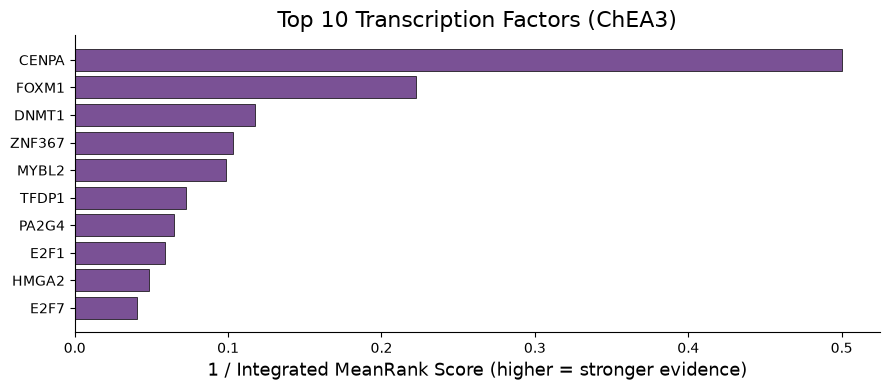

In [8]:
def query_chea3(gene_set, name):
    r = requests.post(
        'https://maayanlab.cloud/chea3/api/enrich/',
        json={'query_name': name, 'gene_set': gene_set},
        headers={'Content-Type': 'application/json'}
    )
    if not r.ok:
        raise APIFailure
    data = r.json()
    if 'Integrated--meanRank' not in data or len(data['Integrated--meanRank']) == 0:
        raise NoResults
    return data

tf_names = []
caption1 = f"**Table 1. Top {top_n_tfs} transcription factors inferred by ChEA3 for `{query_name}`.** Transcription factors are ranked by the Integrated MeanRank method across ChEA3's six reference libraries. Overlapping genes are the members of the input list found among each factor's known target genes."

try:
    chea3 = query_chea3(genes, query_name)
    top_tfs = chea3['Integrated--meanRank'][:top_n_tfs]
    tf_names = [t['TF'] for t in top_tfs]

    chea3_df = pd.DataFrame([
        {
            'Rank': i + 1,
            'Transcription Factor': t['TF'],
            'Score': round(float(t['Score']), 2),
            'Overlapping Genes': ', '.join((t.get('Overlapping_Genes') or [])[:6])
        }
        for i, t in enumerate(top_tfs)
    ])
    display(HTML(f'<strong>Top {top_n_tfs} Transcription Factors (ChEA3)</strong>'))
    display(HTML(chea3_df.to_html(index=False)))
    display(Markdown(caption1))

    # Bar chart: lower MeanRank score = stronger evidence, so invert for display
    inv_score = [1.0 / s if s > 0 else 0 for s in chea3_df['Score']]
    make_bar_chart(
        chea3_df['Transcription Factor'], inv_score,
        title=f'Top {top_n_tfs} Transcription Factors (ChEA3)',
        xlabel='1 / Integrated MeanRank Score (higher = stronger evidence)',
        colors='#7a5195'
    )
    plt.show()
except APIFailure:
    display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>Unable to retrieve results because of a bad response from the ChEA3 API</b></div>"))
    display(HTML("<div style='font-size:1rem; padding:1rem 0;'>Please try again later.</div>"))
except NoResults:
    display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>No transcription factors were returned for this gene set</b></div>"))
    display(HTML("<div style='font-size:1rem; padding:1rem 0;'>Please try again with a different gene list.</div>"))

## Step 2: KEA3 — Upstream Kinase Enrichment
The transcription factors identified in Step 1 become the input gene set for this step: KEA3 infers which kinases are most likely upstream of them, based on kinase-substrate and protein-protein interaction data integrated across multiple libraries via the Mean Rank method.

Rank,Kinase,Score,Overlapping Genes
1,PKCI,6.00,"E2F1, MYBL2, PA2G4, CENPA"
2,FAM20C,12.00,"HMGA2, MYBL2, E2F7"
3,CDK2,14.00,"DNMT1, TFDP1, E2F1, HMGA2, MYBL2, PA2G4"
4,ALK4,15.00,"HMGA2, MYBL2, PA2G4"
5,CDK1,15.09,"DNMT1, TFDP1, E2F1, HMGA2, MYBL2, PA2G4"
6,ATM,20.75,"DNMT1, TFDP1, E2F1, HMGA2, MYBL2, PA2G4"
7,CDK7,21.45,"TFDP1, E2F1, MYBL2, PA2G4, FOXM1, CENPA"
8,MLK3,22.00,"PA2G4, FOXM1, CENPA"
9,CDK4,22.50,"DNMT1, TFDP1, E2F1, HMGA2, MYBL2, PA2G4"
10,CDK6,22.64,"DNMT1, TFDP1, E2F1, HMGA2, MYBL2, PA2G4"


**Table 2. Top 10 upstream kinases inferred by KEA3 for the transcription factors in Table 1.** Kinases are ranked by KEA3's Integrated MeanRank method. Overlapping genes/proteins are members of the query list found among each kinase's putative substrates.

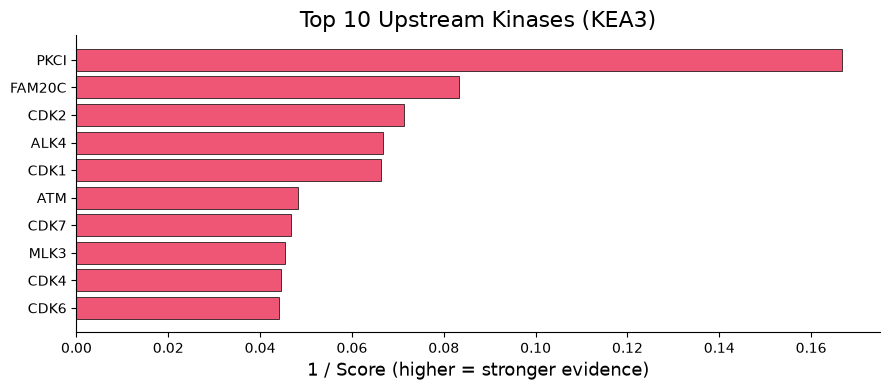

In [9]:
def query_kea3(gene_set, name):
    r = requests.post(
        'https://maayanlab.cloud/kea3/api/enrich/',
        json={'query_name': name, 'gene_set': gene_set}
    )
    if not r.ok:
        raise APIFailure
    data = r.json()
    if not data:
        raise NoResults
    return data

caption2 = f"**Table 2. Top {top_n_kinases} upstream kinases inferred by KEA3 for the transcription factors in Table 1.** Kinases are ranked by KEA3's Integrated MeanRank method. Overlapping genes/proteins are members of the query list found among each kinase's putative substrates."

if not tf_names:
    display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>Skipping KEA3 — no transcription factors available from Step 1</b></div>"))
else:
    try:
        kea3 = query_kea3(tf_names, f'{query_name}_TFs')

        # KEA3 shares its API framework with ChEA3: the response is a DICT keyed
        # by library name (e.g. 'Integrated--meanRank', 'Integrated--topRank',
        # plus one key per individual library), not a list of
        # {'library', 'results'} objects. Each value is a list of per-kinase
        # record dicts.
        mean_rank_key = next(
            (k for k in kea3 if 'meanrank' in k.lower()),
            next(iter(kea3), None)
        )
        top_kinases = kea3.get(mean_rank_key, [])[:top_n_kinases] if mean_rank_key else []
        if not top_kinases:
            raise NoResults

        rows = []
        for i, k in enumerate(top_kinases):
            # Field names vary slightly by library/version, so fall back gracefully.
            name = k.get('TF') or k.get('Kinase') or k.get('kinase') or '?'
            raw_score = k.get('Score', k.get('FET p-value', k.get('FDR', 0)))
            try:
                score = round(float(raw_score), 3)
            except (TypeError, ValueError):
                score = 0.0
            og = k.get('Overlapping_Genes', '')
            if isinstance(og, str):
                genes_overlap = ', '.join(og.split(',')[:6])
            elif isinstance(og, list):
                genes_overlap = ', '.join(og[:6])
            else:
                genes_overlap = ''
            rows.append({'Rank': i + 1, 'Kinase': name, 'Score': score, 'Overlapping Genes': genes_overlap})

        kea3_df = pd.DataFrame(rows)
        display(HTML(f'<strong>Top {top_n_kinases} Upstream Kinases (KEA3 · {mean_rank_key})</strong>'))
        display(HTML(kea3_df.to_html(index=False)))
        display(Markdown(caption2))

        # Bar chart: lower score = stronger evidence, so invert for display
        inv_score = [1.0 / s if s > 0 else 0 for s in kea3_df['Score']]
        make_bar_chart(
            kea3_df['Kinase'], inv_score,
            title=f'Top {top_n_kinases} Upstream Kinases (KEA3)',
            xlabel='1 / Score (higher = stronger evidence)',
            colors='#ef5675'
        )
        plt.show()
    except APIFailure:
        display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>Unable to retrieve results because of a bad response from the KEA3 API</b></div>"))
        display(HTML("<div style='font-size:1rem; padding:1rem 0;'>Please try again later.</div>"))
    except NoResults:
        display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>No kinases were returned for this transcription factor set</b></div>"))
        display(HTML("<div style='font-size:1rem; padding:1rem 0;'>Please try again with a different gene list.</div>"))

## Step 3: Perturb-Seqr — Drug & Gene Perturbation Reversal Candidates
The original input gene list is queried against [Perturb-Seqr](https://perturbseqr.maayanlab.cloud), a connectivity-mapping search engine integrating 9 small-molecule and 7 single-gene perturbation signature collections. For each perturbation, Perturb-Seqr reports how significantly the query gene set overlaps with genes that go *up* after the perturbation and genes that go *down* after the perturbation (Fisher's exact test).

Results are split into four separate tables and charts so drug and gene perturbations, and their up- and down-regulated overlaps, can each be inspected on their own terms:

- **Up Drugs** — small-molecule perturbations whose *up*-regulated genes significantly overlap the query list (same-direction/mimickers).
- **Down Drugs** — small-molecule perturbations whose *down*-regulated genes significantly overlap the query list (reversal candidates).
- **Up Genes** — gene knockout/knockdown perturbations whose *up*-regulated genes significantly overlap the query list.
- **Down Genes** — gene knockout/knockdown perturbations whose *down*-regulated genes significantly overlap the query list (reversal candidates).

Each table is ranked independently by p-value for that direction. Drugs vs. genes are distinguished by querying Perturb-Seqr's 9 named small-molecule libraries directly (`libraryNames`); anything returned by an unrestricted query that isn't in that confirmed drug set is treated as a gene perturbation.

Rank,Perturbation,Odds Ratio,p-value,FDA Approved
1,palbociclib,0.00,1.00e+00,True
2,mitoxantrone,0.00,1.00e+00,True
3,doxorubicin,0.00,1.00e+00,True
4,R-547,0.00,1.00e+00,False
5,saha,0.00,1.00e+00,True
6,etoposide,0.00,1.00e+00,True
7,cobimetinib,0.00,1.00e+00,True
8,dabrafenib,0.00,1.00e+00,True
9,colchicine,0.08,1.00e+00,True
10,Selinexor,0.00,1.00e+00,False


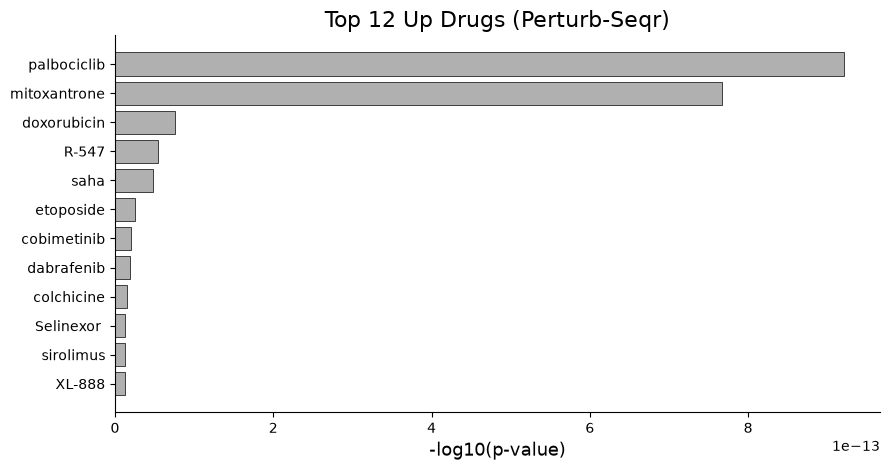

**Figure 1. Top 12 same-direction ('up') drug perturbations for `TNBC_up`,** ranked by -log10(p-value) for overlap with each drug's up-regulated genes.

**Table 3a. Top 12 drug perturbations for `TNBC_up` whose up-regulated genes significantly overlap the query list (same-direction/mimickers).**

Rank,Perturbation,Odds Ratio,p-value,FDA Approved
1,palbociclib,99681.00,1.28e-91,True
2,mitoxantrone,7960.09,1.67e-78,True
3,bortezomib,3171.00,1.83e-54,True
4,saha,1747.67,1.69e-49,True
5,wortmannin,3569.44,1.91e-46,False
6,PD-0325901,17391.00,6.62e-38,False
7,trichostatin-a,3015.57,7.45e-38,False
8,PHA-793887,5797.00,2.09e-36,False
9,MG-132,2537.57,1.72e-34,False
10,R-547,5075.00,5.82e-34,False


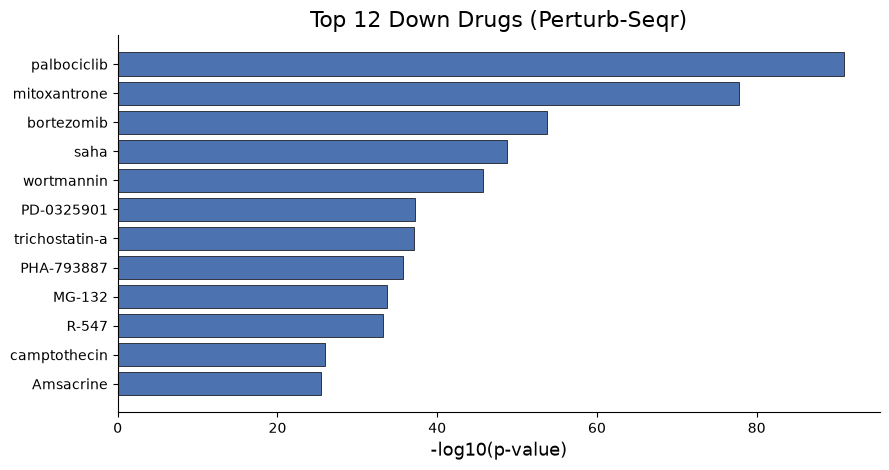

**Figure 2. Top 12 reversal-candidate ('down') drug perturbations for `TNBC_up`,** ranked by -log10(p-value) for overlap with each drug's down-regulated genes.

**Table 3b. Top 12 drug perturbations for `TNBC_up` whose down-regulated genes significantly overlap the query list (reversal candidates).**

Rank,Perturbation,Odds Ratio,p-value,FDA Approved
1,CCNA2,0.00,1.00e+00,False
2,RPL8,0.01,1.00e+00,False
3,PSMA5,0.01,1.00e+00,False
4,RPL19,0.01,1.00e+00,False
5,BRDN0001066248,0.01,1.00e+00,False
6,brf1,1.55,1.00e+00,False
7,prdm16,2.11,1.00e+00,False
8,sirt5,0.01,1.00e+00,False
9,COPA,0.01,1.00e+00,False
10,BRDN0001066155,0.01,1.00e+00,False


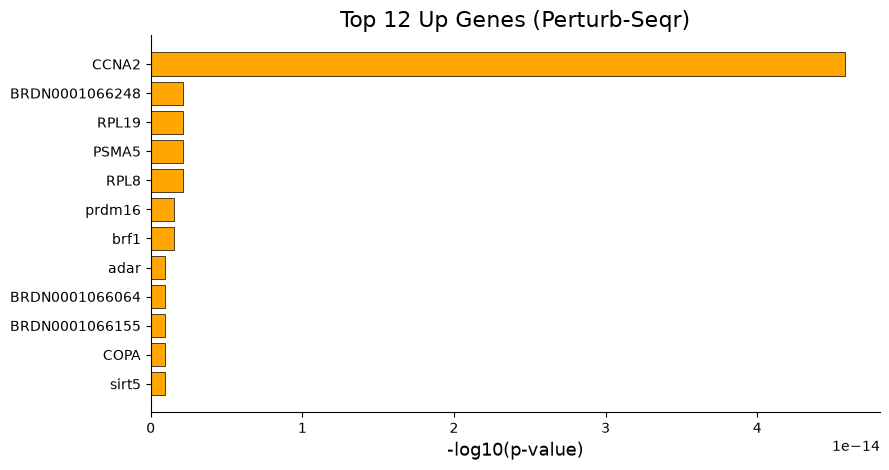

**Figure 3. Top 12 same-direction ('up') gene perturbations for `TNBC_up`,** ranked by -log10(p-value) for overlap with each perturbation's up-regulated genes.

**Table 3c. Top 12 gene knockout/knockdown perturbations for `TNBC_up` whose up-regulated genes significantly overlap the query list.**

Rank,Perturbation,Odds Ratio,p-value,FDA Approved
1,CCNA2,15225.0,1.97e-35,False
2,CDK4,351.0,3.69e-05,False
3,RPL8,153.0,2.02e-03,False
4,PSMA5,153.0,2.02e-03,False
5,RPL19,153.0,2.02e-03,False
6,BRDN0001066248,153.0,2.02e-03,False
7,sirt5,105.0,8.33e-03,False
8,BRDN0001066064,105.0,8.33e-03,False
9,COPA,105.0,8.33e-03,False
10,RPS9,105.0,8.33e-03,False


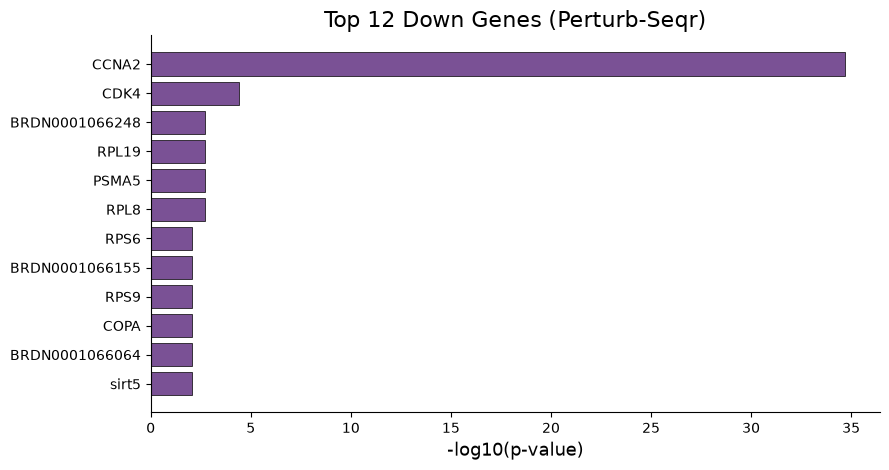

**Figure 4. Top 12 reversal-candidate ('down') gene perturbations for `TNBC_up`,** ranked by -log10(p-value) for overlap with each perturbation's down-regulated genes.

**Table 3d. Top 12 gene knockout/knockdown perturbations for `TNBC_up` whose down-regulated genes significantly overlap the query list (reversal candidates).**

**Figure 5. Combined overview of the top 48 perturbations shown in Tables 3a-3d for `TNBC_up`,** colored by category (grey = up drugs, blue = down drugs, orange = up genes, purple = down genes). Hover over a point for details.

In [10]:
PERTURBSEQR_URL = 'https://perturbseqr.maayanlab.cloud/graphql'

# The 9 documented small-molecule/drug perturbation libraries in Perturb-Seqr.
# Anything NOT returned when restricting to these libraries is treated as a
# gene (knockout/knockdown) perturbation. This avoids relying on the
# undocumented `filterKo` flag, whose direction turned out to be unreliable.
DRUG_LIBRARY_NAMES = [
    'CREEDS Chem', 'DeepCover MoA', 'Ginkgo Bioworks', 'LINCS L1000 CP',
    'Microarrays CMAP', 'NIBR DRUG-seq', 'RummaGEO Chem', 'SciPlex', 'Tahoe-100M',
]

def query_perturbseqr(gene_set, first=2000, library_names=None):
    variables = {
        'filterTerm': '',
        'offset': 0,
        'first': first,
        'filterFda': False,
        'sortBy': 'pvalue_up',
        'filterKo': False,
        'genes': gene_set,
    }
    if library_names is not None:
        variables['libraryNames'] = library_names
    query = {
        'operationName': 'EnrichmentQuery',
        'variables': variables,
        'query': """query EnrichmentQuery(
                $genes: [String]!
                $filterTerm: String = ""
                $offset: Int = 0
                $first: Int = 10
                $filterFda: Boolean = false
                $sortBy: String = ""
                $filterKo: Boolean = false
                $libraryNames: [String]
                ) {
                currentBackground {
                    enrich(
                    genes: $genes
                    filterTerm: $filterTerm
                    offset: $offset
                    first: $first
                    filterFda: $filterFda
                    sortby: $sortBy
                    filterKo: $filterKo
                    libraryNames: $libraryNames
                    ) {
                    consensusCount
                    consensus {
                        drug
                        oddsRatio
                        pvalue
                        adjPvalue
                        approved
                        countSignificant
                        countInsignificant
                        countUpSignificant
                        pvalueUp
                        adjPvalueUp
                        oddsRatioUp
                        pvalueDown
                        adjPvalueDown
                        oddsRatioDown
                    }
                    }
                }
                }
                """,
    }
    r = requests.post(PERTURBSEQR_URL, json=query)
    if not r.ok:
        raise APIFailure
    res = r.json()
    consensus = (res.get('data') or {}).get('currentBackground', {}).get('enrich', {}).get('consensus', [])
    if not consensus:
        raise NoResults
    return pd.DataFrame(consensus).rename(columns={'drug': 'perturbation'})


def build_direction_table(df, top_n, direction):
    """Rank a consensus dataframe by the up- or down-regulation p-value and
    build a display-ready table for that single direction."""
    pcol, ocol = ('pvalueUp', 'oddsRatioUp') if direction == 'up' else ('pvalueDown', 'oddsRatioDown')
    d = df.dropna(subset=[pcol]).copy()
    d = d.sort_values(pcol, ascending=True).head(top_n).reset_index(drop=True)
    d['neg_log_pvalue'] = -np.log10(d[pcol].clip(lower=1e-300))
    table = pd.DataFrame({
        'Rank': range(1, len(d) + 1),
        'Perturbation': d['perturbation'],
        'Odds Ratio': d[ocol].round(2),
        'p-value': d[pcol].map(lambda x: f'{x:.2e}'),
        'FDA Approved': d['approved'],
    })
    return d, table


def show_perturbation_section(d, table, title, xlabel, color, file_stub, fig_caption):
    """Display a table + bar chart for one of the four (up/down x drug/gene)
    categories. Returns the saved chart filename, or None if there were no
    results for this category."""
    if d.empty:
        display(HTML("<div style='font-size:1.05rem; padding:0.5rem 0;'><b>No results in this category for the current gene set.</b></div>"))
        return None
    display(HTML(f'<strong>{title}</strong>'))
    display(HTML(table.to_html(index=False)))
    make_bar_chart(
        table['Perturbation'], d['neg_log_pvalue'],
        title=title,
        xlabel=xlabel,
        colors=color
    )
    bar_file = f"{file_stub}.png".replace(' ', '_')
    plt.savefig(bar_file, bbox_inches='tight')
    plt.show()
    display(Markdown(fig_caption))
    return bar_file


up_drugs_df = down_drugs_df = up_genes_df = down_genes_df = None
up_drugs_table = down_drugs_table = up_genes_table = down_genes_table = None
up_drugs_bar_file = down_drugs_bar_file = up_genes_bar_file = down_genes_bar_file = None
perturbseqr_link = 'https://perturbseqr.maayanlab.cloud'
perturbseqr_ok = False

try:
    # Query 1: restricted to the 9 documented drug-perturbation libraries.
    # This set is trustworthy by construction -- every row really is a drug.
    drugs_all = query_perturbseqr(genes, first=2000, library_names=DRUG_LIBRARY_NAMES)

    # Query 2: unrestricted (all 16 libraries, drugs + genes).
    try:
        consensus_all = query_perturbseqr(genes, first=2000, library_names=None)
    except NoResults:
        consensus_all = drugs_all.copy()

    # Genes = anything in the unrestricted set that isn't a confirmed drug above.
    drug_names = set(drugs_all['perturbation'])
    genes_all = consensus_all[~consensus_all['perturbation'].isin(drug_names)].reset_index(drop=True)
    drugs_all = drugs_all.reset_index(drop=True)

    perturbseqr_ok = True

    # --- Up Drugs ---
    up_drugs_df, up_drugs_table = build_direction_table(drugs_all, top_n_drugs, 'up')
    caption_up_drugs = f"**Table 3a. Top {top_n_drugs} drug perturbations for `{query_name}` whose up-regulated genes significantly overlap the query list (same-direction/mimickers).**"
    up_drugs_bar_file = show_perturbation_section(
        up_drugs_df, up_drugs_table,
        title=f'Top {top_n_drugs} Up Drugs (Perturb-Seqr)',
        xlabel='-log10(p-value)', color='#B0B0B0',
        file_stub=f"{query_name}_up_drugs_bar",
        fig_caption=f"**Figure 1. Top {len(up_drugs_df)} same-direction ('up') drug perturbations for `{query_name}`,** ranked by -log10(p-value) for overlap with each drug's up-regulated genes."
    )
    display(Markdown(caption_up_drugs))

    # --- Down Drugs ---
    down_drugs_df, down_drugs_table = build_direction_table(drugs_all, top_n_drugs, 'down')
    caption_down_drugs = f"**Table 3b. Top {top_n_drugs} drug perturbations for `{query_name}` whose down-regulated genes significantly overlap the query list (reversal candidates).**"
    down_drugs_bar_file = show_perturbation_section(
        down_drugs_df, down_drugs_table,
        title=f'Top {top_n_drugs} Down Drugs (Perturb-Seqr)',
        xlabel='-log10(p-value)', color='#4C72B0',
        file_stub=f"{query_name}_down_drugs_bar",
        fig_caption=f"**Figure 2. Top {len(down_drugs_df)} reversal-candidate ('down') drug perturbations for `{query_name}`,** ranked by -log10(p-value) for overlap with each drug's down-regulated genes."
    )
    display(Markdown(caption_down_drugs))

    # --- Up Genes ---
    up_genes_df, up_genes_table = build_direction_table(genes_all, top_n_genes, 'up')
    caption_up_genes = f"**Table 3c. Top {top_n_genes} gene knockout/knockdown perturbations for `{query_name}` whose up-regulated genes significantly overlap the query list.**"
    up_genes_bar_file = show_perturbation_section(
        up_genes_df, up_genes_table,
        title=f'Top {top_n_genes} Up Genes (Perturb-Seqr)',
        xlabel='-log10(p-value)', color='#ffa600',
        file_stub=f"{query_name}_up_genes_bar",
        fig_caption=f"**Figure 3. Top {len(up_genes_df)} same-direction ('up') gene perturbations for `{query_name}`,** ranked by -log10(p-value) for overlap with each perturbation's up-regulated genes."
    )
    display(Markdown(caption_up_genes))

    # --- Down Genes ---
    down_genes_df, down_genes_table = build_direction_table(genes_all, top_n_genes, 'down')
    caption_down_genes = f"**Table 3d. Top {top_n_genes} gene knockout/knockdown perturbations for `{query_name}` whose down-regulated genes significantly overlap the query list (reversal candidates).**"
    down_genes_bar_file = show_perturbation_section(
        down_genes_df, down_genes_table,
        title=f'Top {top_n_genes} Down Genes (Perturb-Seqr)',
        xlabel='-log10(p-value)', color='#7a5195',
        file_stub=f"{query_name}_down_genes_bar",
        fig_caption=f"**Figure 4. Top {len(down_genes_df)} reversal-candidate ('down') gene perturbations for `{query_name}`,** ranked by -log10(p-value) for overlap with each perturbation's down-regulated genes."
    )
    display(Markdown(caption_down_genes))

    # --- Combined interactive overview across all four categories ---
    def _tag(d, cat):
        if d is None or d.empty:
            return pd.DataFrame()
        t = d.copy()
        t['category'] = cat
        t['x'] = t['oddsRatioUp'] if cat.startswith('Up') else t['oddsRatioDown']
        return t

    combined = pd.concat([
        _tag(up_drugs_df, 'Up Drug'),
        _tag(down_drugs_df, 'Down Drug'),
        _tag(up_genes_df, 'Up Gene'),
        _tag(down_genes_df, 'Down Gene'),
    ], ignore_index=True)

    if not combined.empty:
        cat_colors = {'Up Drug': '#B0B0B0', 'Down Drug': '#4C72B0', 'Up Gene': '#ffa600', 'Down Gene': '#7a5195'}
        combined['colors'] = combined['category'].map(cat_colors)

        source = ColumnDataSource(data=dict(
            x=combined['x'],
            y=combined['neg_log_pvalue'],
            perturbation=combined['perturbation'],
            category=combined['category'],
            colors=combined['colors'],
        ))
        hover = HoverTool(tooltips=[
            ('Perturbation', '@perturbation'),
            ('Category', '@category'),
            ('-log10(p-value)', '@y'),
            ('Odds Ratio', '@x'),
        ])
        volcano_plot = figure(
            width=700, height=500,
            tools=[hover, 'pan', 'wheel_zoom', 'reset', 'save'],
            title='Perturb-Seqr Overview: Up/Down Drugs & Genes'
        )
        volcano_plot.circle('x', 'y', size=10, fill_color='colors', line_color='colors', fill_alpha=0.7, line_alpha=0.7, source=source)
        volcano_plot.xaxis.axis_label = 'Odds Ratio'
        volcano_plot.yaxis.axis_label = '-log10(p-value)'
        volcano_plot.output_backend = 'svg'
        show(volcano_plot)
        display(Markdown(f"**Figure 5. Combined overview of the top {len(combined)} perturbations shown in Tables 3a-3d for `{query_name}`,** colored by category (grey = up drugs, blue = down drugs, orange = up genes, purple = down genes). Hover over a point for details."))

except APIFailure:
    display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>Unable to retrieve results because of a bad response from the Perturb-Seqr API</b></div>"))
    display(HTML("<div style='font-size:1rem; padding:1rem 0;'>Please try again later.</div>"))
except NoResults:
    display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>No perturbations were returned for this gene set</b></div>"))
    display(HTML("<div style='font-size:1rem; padding:1rem 0;'>Please try again with a different gene list.</div>"))


## Link to Perturb-Seqr

In [11]:
# Link to the Perturb-Seqr web app for further exploration
if perturbseqr_ok:
    display(HTML(f"<div style='font-size:1.25rem; padding:1rem 0;'><a href='{perturbseqr_link}' target='_blank'>Explore the complete Perturb-Seqr connectivity mapping database online.</a></div>"))
else:
    display(HTML("<div style='font-size:1.5rem; padding:1rem 0;'><b>No Perturb-Seqr results available for the current query</b></div>"))
    display(HTML("<div style='font-size:1rem; padding:1rem 0;'>Please try again with a different input list.</div>"))

## Save Full Pipeline Report
Combine the results and charts from all three steps (ChEA3, KEA3, Perturb-Seqr) into a single standalone HTML report file that can be downloaded and shared.

In [12]:
# Save combined results and charts from all three steps into a single HTML report
from datetime import datetime

def _safe_table_html(df_name, table_name, caption_name, image_file=None):
    df = globals().get(table_name) if globals().get(table_name) is not None else globals().get(df_name)
    caption = globals().get(caption_name, '')
    if df is not None and len(df) > 0:
        img_html = f"<img src='{image_file}' style='max-width:100%; margin-top:1rem;'>" if image_file else ''
        return f"<div>{df.to_html(index=False)}</div>{img_html}<p>{caption}</p>"
    else:
        return "<p><i>No results were available for this step.</i></p>"

report_sections = []
report_sections.append("<h2>Step 1: ChEA3 &mdash; Transcription Factor Enrichment</h2>")
report_sections.append(_safe_table_html('chea3_df', 'chea3_df', 'caption1'))
report_sections.append("<h2>Step 2: KEA3 &mdash; Upstream Kinase Enrichment</h2>")
report_sections.append(_safe_table_html('kea3_df', 'kea3_df', 'caption2'))

report_sections.append("<h2>Step 3: Perturb-Seqr &mdash; Drug &amp; Gene Perturbation Candidates</h2>")
report_sections.append("<h3>Up Drugs</h3>")
report_sections.append(_safe_table_html('up_drugs_df', 'up_drugs_table', 'caption_up_drugs', image_file=globals().get('up_drugs_bar_file')))
report_sections.append("<h3>Down Drugs</h3>")
report_sections.append(_safe_table_html('down_drugs_df', 'down_drugs_table', 'caption_down_drugs', image_file=globals().get('down_drugs_bar_file')))
report_sections.append("<h3>Up Genes</h3>")
report_sections.append(_safe_table_html('up_genes_df', 'up_genes_table', 'caption_up_genes', image_file=globals().get('up_genes_bar_file')))
report_sections.append("<h3>Down Genes</h3>")
report_sections.append(_safe_table_html('down_genes_df', 'down_genes_table', 'caption_down_genes', image_file=globals().get('down_genes_bar_file')))

if globals().get('perturbseqr_ok'):
    report_sections.append(f"<p><a href='{perturbseqr_link}' target='_blank'>Explore the complete Perturb-Seqr connectivity mapping database online.</a> (The interactive overview plot for this run is available in the notebook.)</p>")

html_report = f"""<html>
<head>
<meta charset="utf-8">
<title>TNBC Regulatory Pipeline Report - {query_name}</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 2rem; color: #222; }}
  table {{ border-collapse: collapse; margin-bottom: 1rem; }}
  th, td {{ border: 1px solid #ccc; padding: 6px 10px; text-align: left; }}
  th {{ background-color: #f2f2f2; }}
  h1 {{ border-bottom: 2px solid #333; padding-bottom: 0.5rem; }}
  h2 {{ margin-top: 2rem; color: #333; }}
  h3 {{ margin-top: 1.5rem; color: #555; }}
</style>
</head>
<body>
<h1>TNBC Regulatory Pipeline Report: {query_name}</h1>
<p>Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
{''.join(report_sections)}
</body>
</html>
"""

report_filename = f"{query_name}_pipeline_report.html".replace(' ', '_')
with open(report_filename, 'w') as f:
    f.write(html_report)

display(HTML(f"<div style='font-size:1.25rem; padding:1rem 0;'>Full pipeline report saved to <code>{report_filename}</code></div>"))
display(HTML(f'<div>Download full report: <a href="{report_filename}" target=_blank>{report_filename}</a></div>'))
